In [1]:
# =============================================================================
# CELDA 1: Importaciones y Configuración Estética
# =============================================================================
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import warnings

warnings.simplefilter('ignore')

# Configuración visual para papers/presentaciones
plt.style.use('seaborn-v0_8-paper')
plt.rcParams.update({
    'font.size': 12, 
    'axes.labelsize': 14, 
    'axes.titlesize': 16, 
    'legend.fontsize': 12,
    'figure.figsize': (10, 6)
})

# Diccionarios de estilo
COLORS = {'Proton': 'royalblue', 'Helio': 'forestgreen', 'Oxigeno': 'purple', 'Hierro': 'firebrick', 'Mix': 'dimgray'}
MARKERS = {'SIBYLL': 'o', 'QGSJet': 's', 'EPOS': '^'}
LINES = {'SIBYLL': '-', 'QGSJet': '--', 'EPOS': ':'}

In [2]:
# =============================================================================
# CELDA 2: Funciones Auxiliares (Ajustes, MF y Parseo)
# =============================================================================

def parse_metadata(folder_name):
    """Extrae metadatos basados en el nombre de la carpeta (ej. parquet_sib_proton_17)."""
    f = folder_name.lower()
    model = 'SIBYLL' if 'sib' in f else 'QGSJet' if 'qgs' in f else 'EPOS' if 'epos' in f else 'Unknown'
    
    if 'proton' in f: primary = 'Proton'
    elif 'hierro' in f or 'iron' in f: primary = 'Hierro'
    elif 'helio' in f or 'helium' in f: primary = 'Helio'
    elif 'oxigeno' in f or 'oxygen' in f: primary = 'Oxigeno'
    else: primary = 'Unknown'
        
    energy = '18.0-18.5' if '_18' in f else '17.5-18.0'
    return model, primary, energy

def fit_func(phi_rad, A1):
    """Función de asimetría del primer armónico."""
    return 1.0 * (1 + A1 * np.cos(phi_rad))

def calc_mf(val1, err1, val2, err2):
    """Calcula el Factor de Mérito (Merit Factor) entre dos distribuciones."""
    denom = np.sqrt(err1**2 + err2**2)
    if denom == 0: return 0.0
    return np.abs(val1 - val2) / denom

def ang_diff(a_deg, b_deg):
    return (a_deg - b_deg + 180) % 360 - 180

In [14]:
# =============================================================================
# CELDA 3: Carga Masiva de Datos
# =============================================================================
ROOT_DIR = "/home/lsilva/Github/ADST_Alexey_module_v9" 

all_dfs = []
for folder in os.listdir(ROOT_DIR):
    folder_path = os.path.join(ROOT_DIR, folder)
    if not os.path.isdir(folder_path): continue
        
    model, primary, energy = parse_metadata(folder)
    parquets = glob.glob(os.path.join(folder_path, "*.parquet"))
    
    for f in parquets:
        try:
            # Cargar columnas relevantes para no reventar la RAM
            df = pd.read_parquet(f, columns=[
                'event_id', 'counterId', 'theta_REC', 'phi_REC', 'logE_REC', 'logE_MC',
                'nMuones_REC', 'nMuones_MC', 'sdSignal_REC', 'sd_nMuons_MC', 'sd_nEM_MC', 'r_core',
                'phi_plane_sp', 'phi_plane_euler', 'phi_plane_ground', 'module_status'
            ])
            df = df.dropna(subset=['theta_REC', 'phi_REC', 'logE_REC'])
            df['Model'], df['Primary'], df['Energy'] = model, primary, energy
            all_dfs.append(df)
        except: pass

df_master = pd.concat(all_dfs, ignore_index=True)

# Dataset Guía para toda la primera parte: SIBYLL Proton 17.5
df_guia = df_master[(df_master['Model'] == 'SIBYLL') & (df_master['Primary'] == 'Proton') & (df_master['Energy'] == '17.5-18.0')].copy()
print(f"Data cargada. Mega-DF: {len(df_master):,} | Dataset Guía (SIB P 17.5): {len(df_guia):,}")

Data cargada. Mega-DF: 9,948,348 | Dataset Guía (SIB P 17.5): 1,532,829


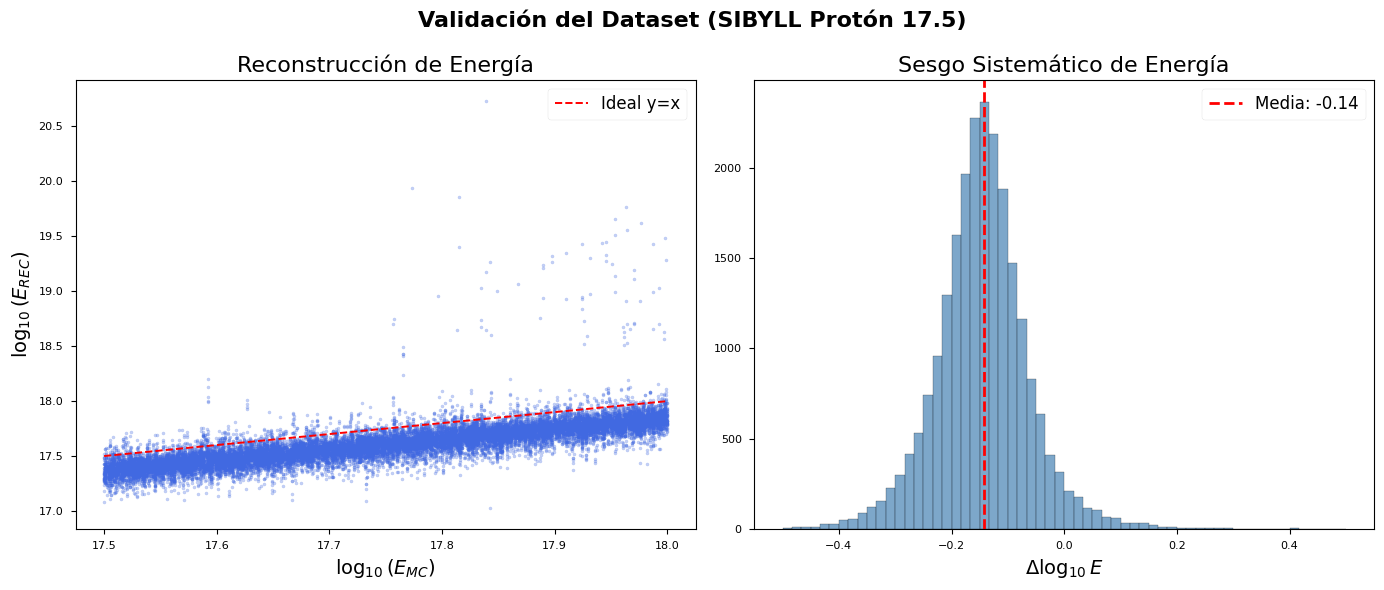

In [16]:
events_guia = df_guia[['event_id', 'logE_MC', 'logE_REC']].drop_duplicates()
deltaE = events_guia['logE_REC'] - events_guia['logE_MC']

fig, axs = plt.subplots(1, 2, figsize=(14, 6))

axs[0].scatter(events_guia['logE_MC'], events_guia['logE_REC'], s=5, alpha=0.3, color='royalblue')
axs[0].plot([17.5, 18], [17.5, 18], 'r--', label='Ideal y=x')
axs[0].set(xlabel=r'$\log_{10}(E_{MC})$', ylabel=r'$\log_{10}(E_{REC})$', title='Reconstrucción de Energía')
axs[0].legend()

axs[1].hist(deltaE, bins=60, range=(-0.5, 0.5), color='steelblue', edgecolor='black', alpha=0.7)
axs[1].axvline(deltaE.mean(), color='r', linestyle='--', lw=2, label=f'Media: {deltaE.mean():.2f}')
axs[1].set(xlabel=r'$\Delta \log_{10}E$', title='Sesgo Sistemático de Energía')
axs[1].legend()

plt.suptitle("Validación del Dataset (SIBYLL Protón 17.5)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

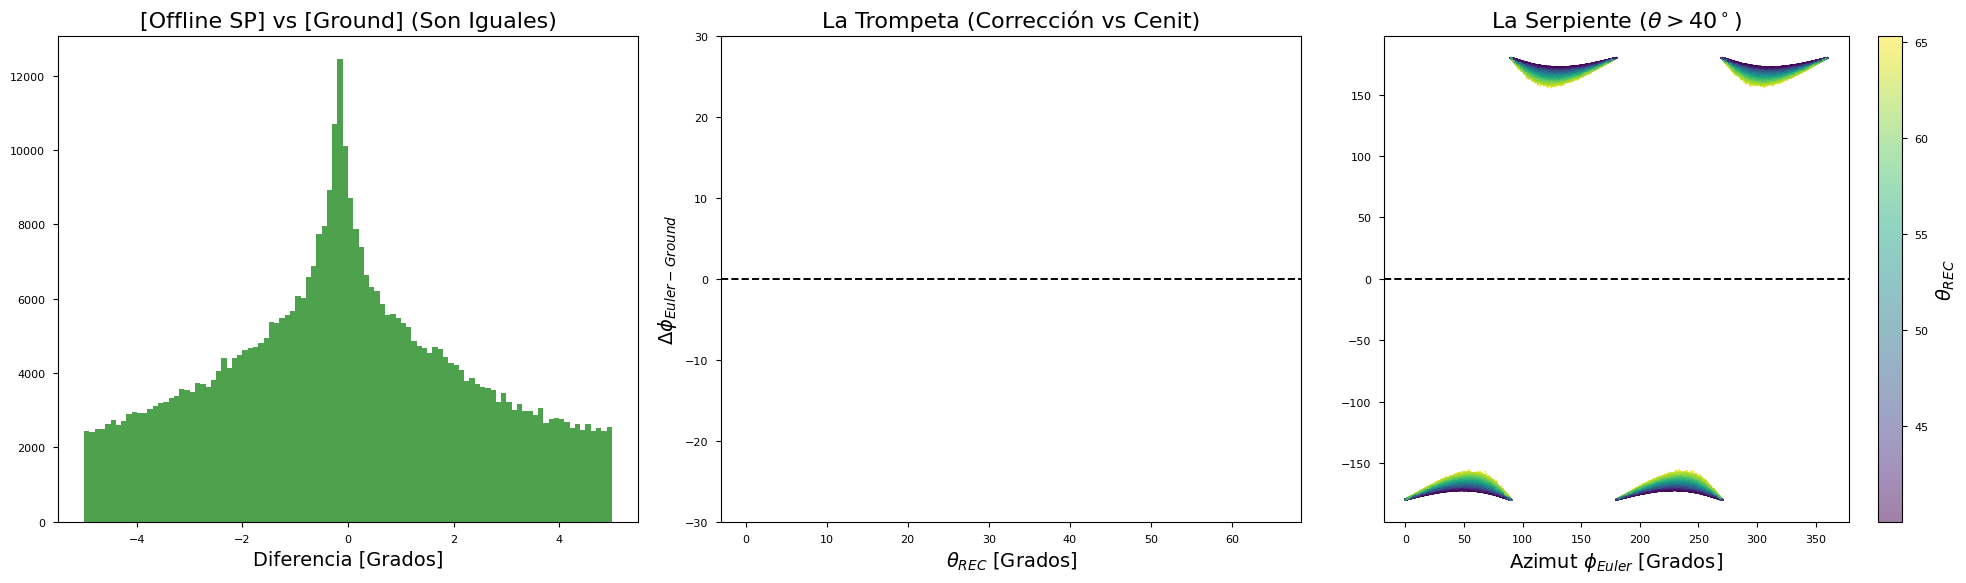

In [17]:
infill_guia = df_guia[df_guia['counterId'] >= 100000].copy()

# Calculamos diferencias
phi_sp_deg = np.rad2deg(infill_guia['phi_plane_sp']) + infill_guia['phi_REC'] # SP crudo necesita sumarle phi_REC
phi_ground_deg = np.rad2deg(infill_guia['phi_plane_ground'])
phi_euler_deg = np.rad2deg(infill_guia['phi_plane_euler'])

diff_offline = ang_diff(phi_sp_deg, phi_ground_deg)
diff_euler = ang_diff(phi_euler_deg, phi_ground_deg)

fig, axs = plt.subplots(1, 3, figsize=(20, 6))

# 1. El Diagnóstico (Histograma)
axs[0].hist(diff_offline, bins=100, range=(-5, 5), color='forestgreen', alpha=0.8)
axs[0].set(xlabel='Diferencia [Grados]', title='[Offline SP] vs [Ground] (Son Iguales)')

# 2. La Trompeta
axs[1].scatter(infill_guia['theta_REC'], diff_euler, s=1, alpha=0.2, c='royalblue')
axs[1].axhline(0, color='k', linestyle='--')
axs[1].set(xlabel=r'$\theta_{REC}$ [Grados]', ylabel=r'$\Delta\phi_{Euler-Ground}$', title='La Trompeta (Corrección vs Cenit)')
axs[1].set_ylim(-30, 30)

# 3. La Serpiente
mask_40 = infill_guia['theta_REC'] > 40
phi_euler_fixed = (phi_euler_deg + 180) % 360
sc = axs[2].scatter(phi_euler_fixed[mask_40], diff_euler[mask_40], c=infill_guia.loc[mask_40, 'theta_REC'], cmap='viridis', s=1, alpha=0.5)
axs[2].axhline(0, color='k', linestyle='--')
axs[2].set(xlabel=r'Azimut $\phi_{Euler}$ [Grados]', title=r'La Serpiente ($\theta > 40^\circ$)')
plt.colorbar(sc, ax=axs[2], label=r'$\theta_{REC}$')

plt.tight_layout()
plt.show()

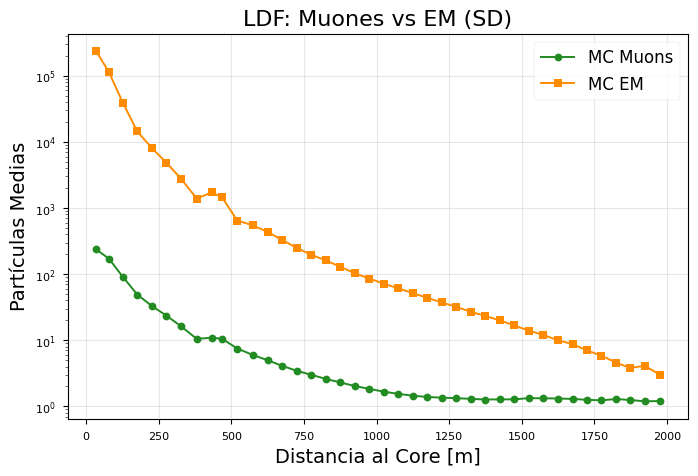

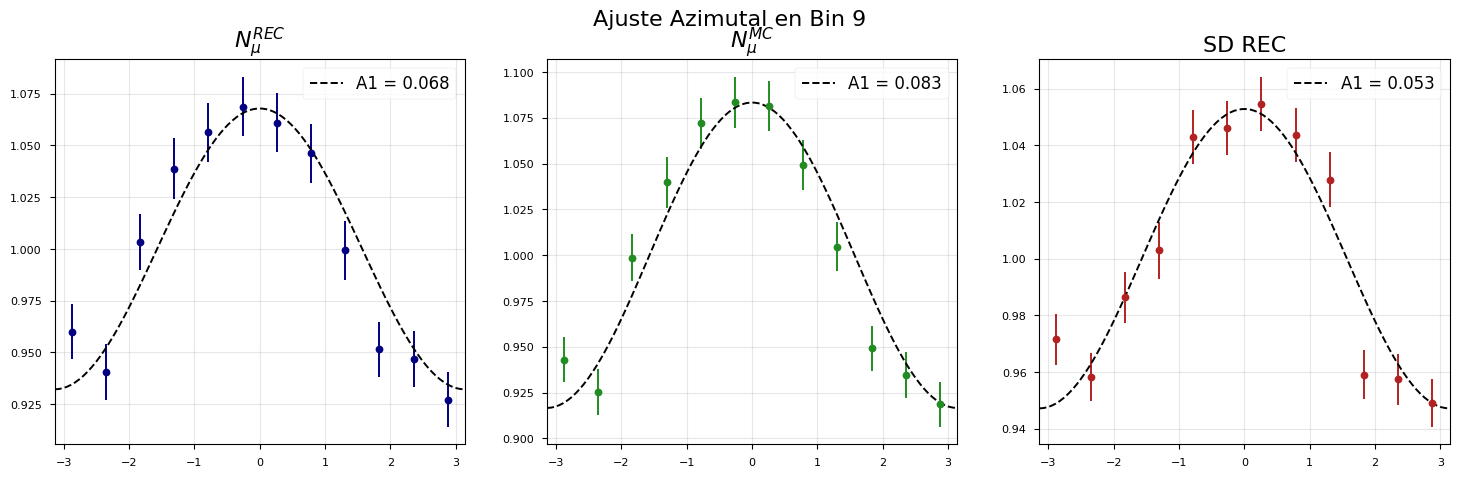

In [20]:
# LDF (Plot 7 de tu reporte original)
r_bins = np.linspace(0, 2000, 41)
df_guia['r_bin'] = pd.cut(df_guia['r_core'], bins=r_bins)
comp_stats = df_guia.groupby('r_bin', observed=True)[['r_core', 'sd_nMuons_MC', 'sd_nEM_MC']].mean().dropna()

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(comp_stats['r_core'], comp_stats['sd_nMuons_MC'], 'o-', color='forestgreen', label='MC Muons')
ax1.plot(comp_stats['r_core'], comp_stats['sd_nEM_MC'], 's-', color='darkorange', label='MC EM')
ax1.set(xlabel="Distancia al Core [m]", ylabel="Partículas Medias", yscale='log', title="LDF: Muones vs EM (SD)")
ax1.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Ajuste A1 (Ejemplo Bin Theta inclinado)
umd_guia = df_guia[(df_guia['counterId'] >= 90000) & (df_guia['counterId'] < 100000)].copy()
s2_bins = np.linspace(np.sin(np.deg2rad(0))**2, np.sin(np.deg2rad(65))**2, 11)
umd_guia['theta_bin'] = pd.cut(umd_guia['theta_REC'], bins=np.rad2deg(np.arcsin(np.sqrt(s2_bins))), labels=False)

bin_target = 9 # Bin inclinado
df_bin = umd_guia[umd_guia['theta_bin'] == bin_target].copy()
df_bin['phi_rad'] = np.deg2rad((np.rad2deg(df_bin['phi_plane_sp']) + 180) % 360 - 180)
df_bin['phi_bin'] = pd.cut(df_bin['phi_rad'], bins=np.linspace(-np.pi, np.pi, 13))

fig, axs = plt.subplots(1, 3, figsize=(18, 5))
configs = [('nMuones_REC', r'$N_\mu^{REC}$', 'navy'), ('nMuones_MC', r'$N_\mu^{MC}$', 'forestgreen'), ('sdSignal_REC', 'SD REC', 'firebrick')]
phi_centers = (np.linspace(-np.pi, np.pi, 13)[:-1] + np.linspace(-np.pi, np.pi, 13)[1:]) / 2

for ax, (col, label, color) in zip(axs, configs):
    prof = df_bin.groupby('phi_bin', observed=True)[col].agg(['mean', 'sem']).dropna()
    norm = prof['mean'].mean()
    y, yerr = prof['mean'] / norm, prof['sem'] / norm
    ax.errorbar(phi_centers, y, yerr=yerr, fmt='o', color=color, capsize=4)
    
    popt, _ = curve_fit(fit_func, phi_centers, y, p0=[0.05], sigma=yerr)
    ax.plot(np.linspace(-np.pi, np.pi, 100), fit_func(np.linspace(-np.pi, np.pi, 100), popt[0]), 'k--', label=f'A1 = {popt[0]:.3f}')
    ax.set(title=label, xlim=(-np.pi, np.pi)); ax.legend(); ax.grid(alpha=0.3)
plt.suptitle(f"Ajuste Azimutal en Bin {bin_target}", fontsize=16)
plt.show()

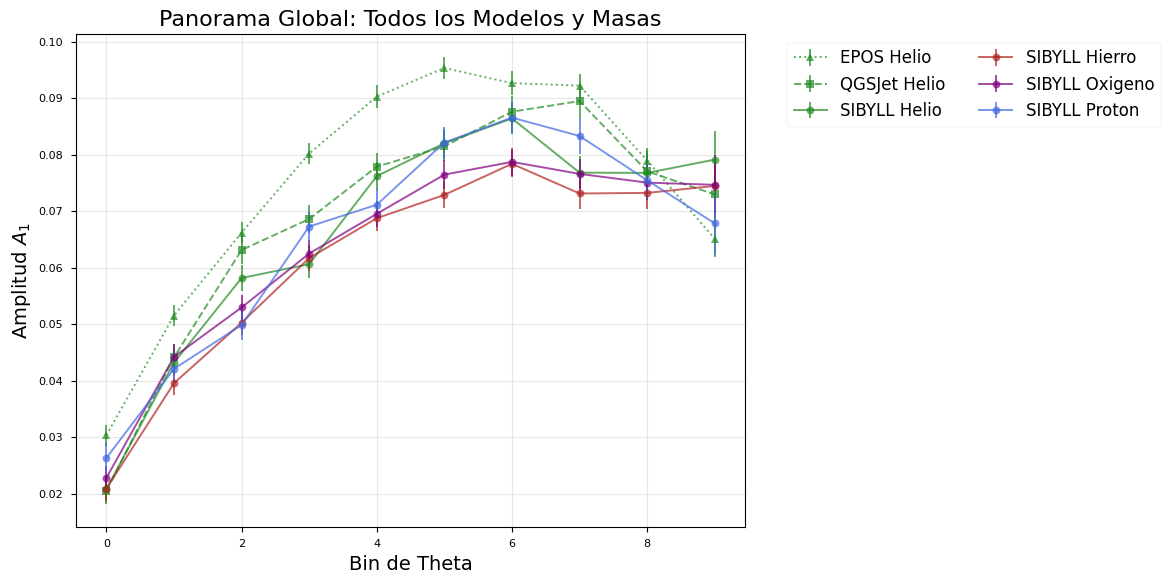

In [21]:
# Calcular A1 para TODO
results = []
df_umd = df_master[(df_master['counterId'] >= 90000) & (df_master['counterId'] < 100000)].copy()
df_umd['theta_bin'] = pd.cut(df_umd['theta_REC'], bins=np.rad2deg(np.arcsin(np.sqrt(s2_bins))), labels=False)
df_umd['phi_rad'] = np.deg2rad((np.rad2deg(df_umd['phi_plane_sp']) + 180) % 360 - 180)
df_umd['phi_bin'] = pd.cut(df_umd['phi_rad'], bins=np.linspace(-np.pi, np.pi, 13))

def get_a1(sub_df):
    prof = sub_df.groupby('phi_bin', observed=True)['nMuones_REC'].agg(['mean', 'sem']).dropna()
    if len(prof) < 8: return np.nan, np.nan
    norm = prof['mean'].mean()
    try:
        popt, pcov = curve_fit(fit_func, phi_centers, prof['mean']/norm, p0=[0.05], sigma=prof['sem']/norm, absolute_sigma=True)
        return popt[0], np.sqrt(pcov[0,0])
    except: return np.nan, np.nan

# Datos Reales
for (mod, prim, en, th_idx), sub_df in df_umd.groupby(['Model', 'Primary', 'Energy', 'theta_bin']):
    a1, err = get_a1(sub_df)
    results.append({'Model': mod, 'Primary': prim, 'Energy': en, 'ThetaBin': th_idx, 'A1': a1, 'Err': err})

# El MIX (Ignorando 'Primary' en el groupby)
for (mod, en, th_idx), sub_df in df_umd.groupby(['Model', 'Energy', 'theta_bin']):
    a1, err = get_a1(sub_df)
    results.append({'Model': mod, 'Primary': 'Mix', 'Energy': en, 'ThetaBin': th_idx, 'A1': a1, 'Err': err})

df_res = pd.DataFrame(results).dropna()

# Plot Global
plt.figure(figsize=(12, 6))
plot_data = df_res[(df_res['Primary'] != 'Mix') & (df_res['A1'] > -0.05) & (df_res['A1'] < 0.15)]
for (mod, prim), group in plot_data.groupby(['Model', 'Primary']):
    group = group.sort_values('ThetaBin')
    plt.errorbar(group['ThetaBin'], group['A1'], yerr=group['Err'], fmt=MARKERS.get(mod)+LINES.get(mod), 
                 color=COLORS.get(prim), label=f"{mod} {prim}", alpha=0.7, capsize=3)
plt.xlabel("Bin de Theta"); plt.ylabel(r"Amplitud $A_1$"); plt.title("Panorama Global: Todos los Modelos y Masas")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

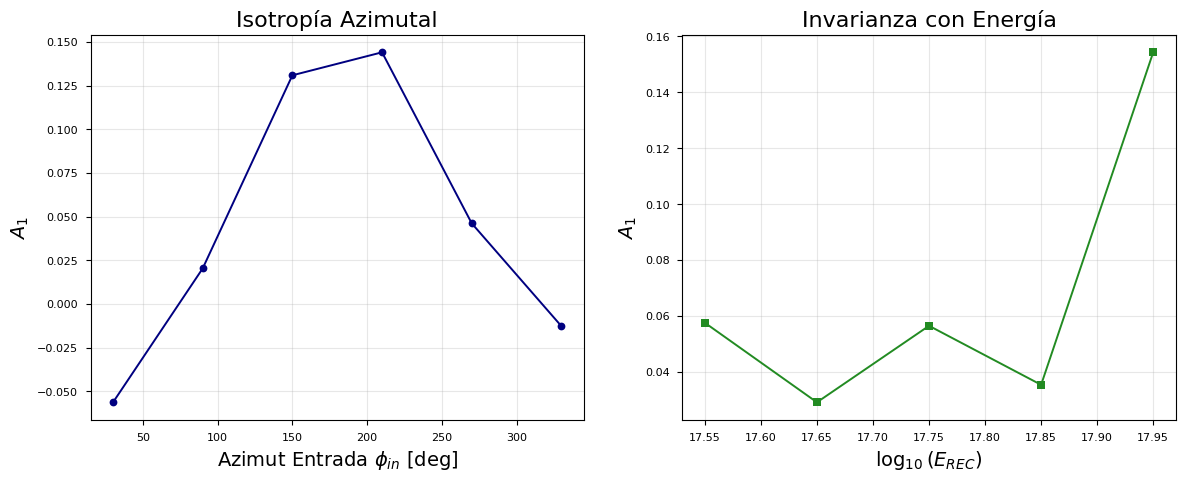

In [22]:
# Usamos el Bin 8 de SIB Proton 17.5 para los sistematicos
df_sys = df_guia[(df_guia['theta_REC'] > 50) & (df_guia['theta_REC'] < 56) & (df_guia['counterId'] >= 90000)].copy()
df_sys['phi_rad'] = np.deg2rad((np.rad2deg(df_sys['phi_plane_sp']) + 180) % 360 - 180)
df_sys['phi_bin'] = pd.cut(df_sys['phi_rad'], bins=np.linspace(-np.pi, np.pi, 13))

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Isotropia
res_iso = []
df_sys['phi_in_bin'] = pd.cut(df_sys['phi_REC'], bins=np.linspace(0, 360, 7))
for bin_name, sub_df in df_sys.groupby('phi_in_bin', observed=True):
    a1, err = get_a1(sub_df)
    res_iso.append(a1)
axs[0].plot(np.linspace(30, 330, 6), res_iso, 'o-', color='navy')
axs[0].set(xlabel='Azimut Entrada $\phi_{in}$ [deg]', ylabel='$A_1$', title='Isotropía Azimutal')
axs[0].grid(alpha=0.3)

# Energia
res_en = []
df_sys['e_bin'] = pd.cut(df_sys['logE_REC'], bins=np.linspace(17.5, 18.0, 6))
for bin_name, sub_df in df_sys.groupby('e_bin', observed=True):
    a1, err = get_a1(sub_df)
    res_en.append(a1)
axs[1].plot(np.linspace(17.55, 17.95, 5), res_en, 's-', color='forestgreen')
axs[1].set(xlabel='$\log_{10}(E_{REC})$', ylabel='$A_1$', title='Invarianza con Energía')
axs[1].grid(alpha=0.3)
plt.show()

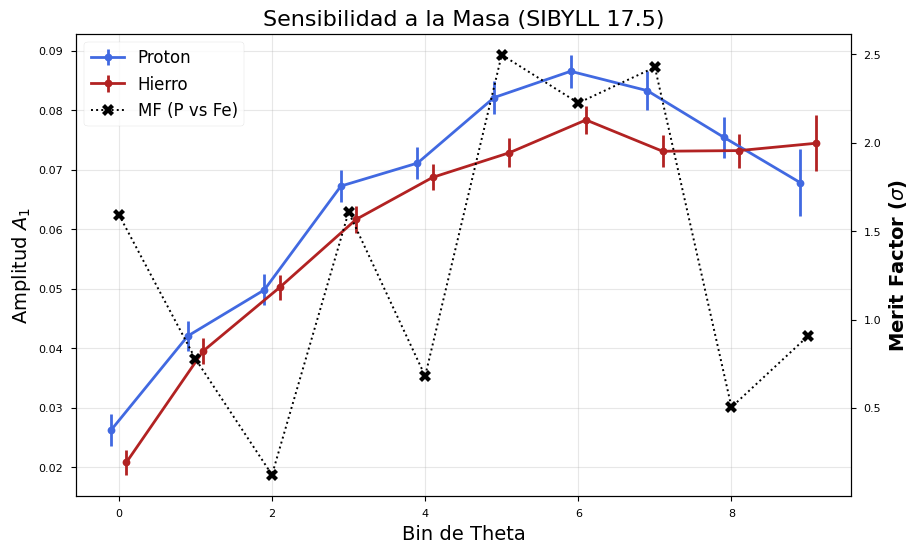

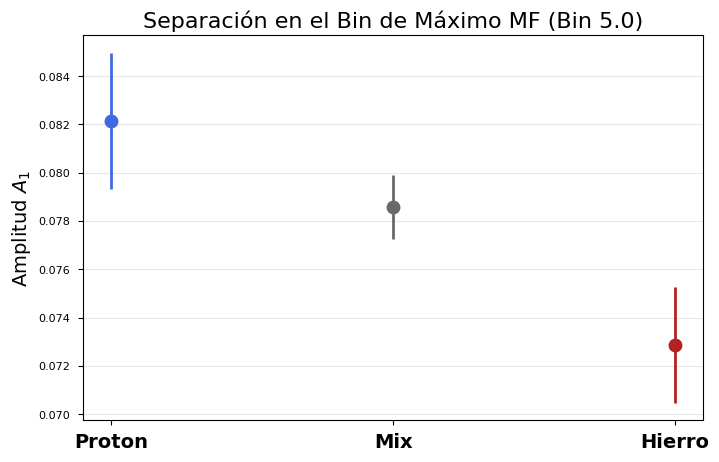

In [23]:
money_data = df_res[(df_res['Model'] == 'SIBYLL') & (df_res['Energy'] == '17.5-18.0')]

# 1. Evolución P vs Fe con Eje MF
fig, ax1 = plt.subplots(figsize=(10, 6))
shifts = {'Proton': -0.1, 'Hierro': 0.1}

for prim in ['Proton', 'Hierro']:
    g = money_data[money_data['Primary'] == prim].sort_values('ThetaBin')
    ax1.errorbar(g['ThetaBin'] + shifts[prim], g['A1'], yerr=g['Err'], fmt='o-', color=COLORS[prim], label=prim, lw=2, capsize=4)

p_data = money_data[money_data['Primary'] == 'Proton'].set_index('ThetaBin')
fe_data = money_data[money_data['Primary'] == 'Hierro'].set_index('ThetaBin')
common = p_data.index.intersection(fe_data.index)

mf_vals = [calc_mf(p_data.loc[b, 'A1'], p_data.loc[b, 'Err'], fe_data.loc[b, 'A1'], fe_data.loc[b, 'Err']) for b in common]

ax2 = ax1.twinx()
ax2.plot(common, mf_vals, 'k:', marker='X', markersize=8, label='MF (P vs Fe)')
ax1.set(xlabel='Bin de Theta', ylabel='Amplitud $A_1$', title='Sensibilidad a la Masa (SIBYLL 17.5)')
ax2.set_ylabel('Merit Factor ($\sigma$)', color='black', fontweight='bold')
lines1, labels1 = ax1.get_legend_handles_labels(); lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left'); ax1.grid(alpha=0.3)
plt.show()

# 2. El BIN de MÁXIMO MF con el MIX
max_bin = common[np.argmax(mf_vals)]
bin_data = money_data[money_data['ThetaBin'] == max_bin]

fig, ax = plt.subplots(figsize=(8, 5))
x_pos = [1, 2, 3]
prims = ['Proton', 'Mix', 'Hierro']
vals = [bin_data[bin_data['Primary'] == p]['A1'].values[0] for p in prims]
errs = [bin_data[bin_data['Primary'] == p]['Err'].values[0] for p in prims]

for x, p, v, e in zip(x_pos, prims, vals, errs):
    ax.errorbar(x, v, yerr=e, fmt='o', color=COLORS[p], markersize=10, capsize=6, lw=2)
    
ax.set_xticks(x_pos); ax.set_xticklabels(prims, fontsize=14, fontweight='bold')
ax.set(ylabel='Amplitud $A_1$', title=f'Separación en el Bin de Máximo MF (Bin {max_bin})')
ax.grid(axis='y', alpha=0.3)
plt.show()

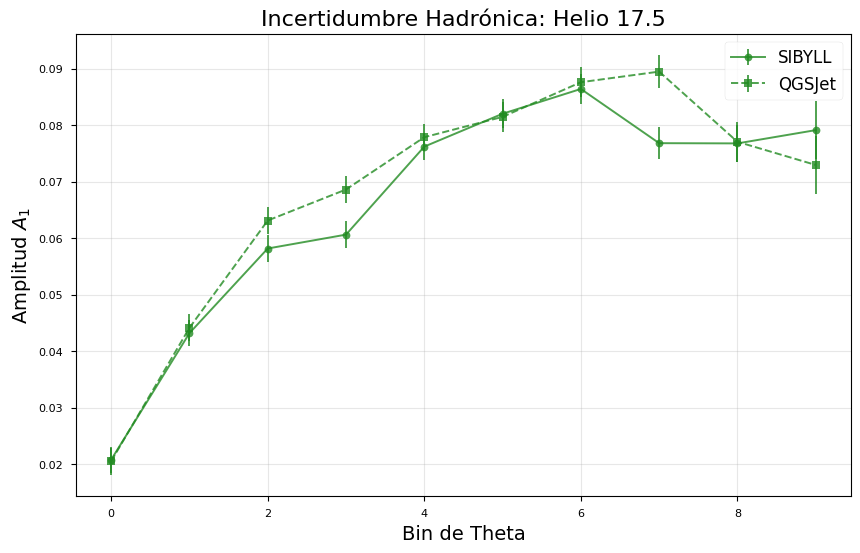

In [24]:
# SIBYLL vs QGSJet para Helio 17.5-18.0
he_data = df_res[(df_res['Primary'] == 'Helio') & (df_res['Energy'] == '17.5-18.0') & (df_res['Model'].isin(['SIBYLL', 'QGSJet']))]

fig, ax = plt.subplots(figsize=(10, 6))
for mod in ['SIBYLL', 'QGSJet']:
    g = he_data[he_data['Model'] == mod].sort_values('ThetaBin')
    ax.errorbar(g['ThetaBin'], g['A1'], yerr=g['Err'], fmt=MARKERS[mod]+LINES[mod], color='forestgreen', label=mod, alpha=0.8, capsize=4)

ax.set(xlabel='Bin de Theta', ylabel='Amplitud $A_1$', title='Incertidumbre Hadrónica: Helio 17.5')
ax.legend(); ax.grid(True, alpha=0.3)
plt.show()